14.517239494178947


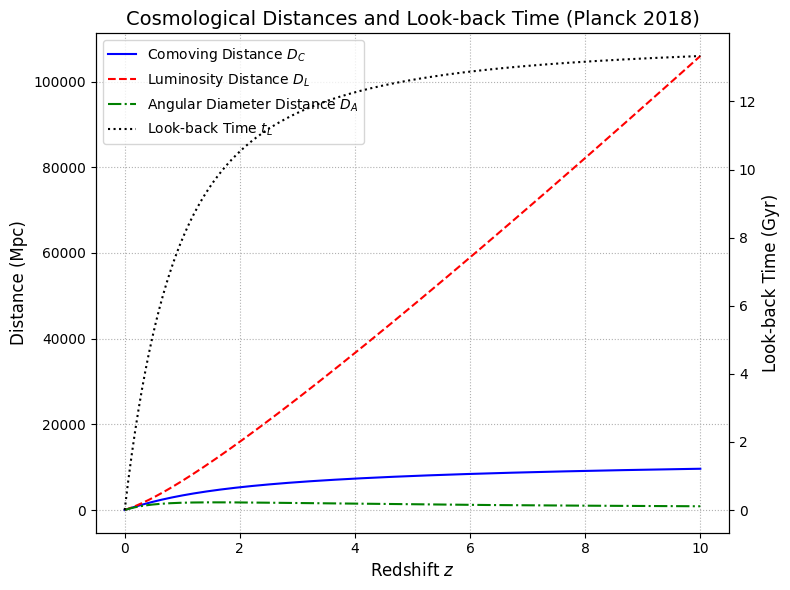

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad # 指定された区間における関数の定積分を高精度に計算

# 宇宙論パラメーターの設定(Planck 2018)
H0 = 67.4 # km/(s・Mpc)
Om0 = 0.315 # Omega_m,0
Ode0 = 0.685 # Omega_Lambda,0
c = 299792.458 # 光速(km/s)

# ハッブル距離(Mpc)とハッブル時間(Gyr)の計算
D_H = c/H0 # ハッブル距離
Mpc_to_km = 3.08567758e19
Gyr_to_sec = 3.1536e16
t_H = (Mpc_to_km/H0)/Gyr_to_sec # 約14.5Gyr
print(t_H)

# 被積分関数の定義
def E(z): # 膨張係数
    return np.sqrt(Om0*((1+z)**3)+Ode0)

def comoving_integrand(z): # 共同距離を求めるための被積分関数
    return 1.0/E(z)

def lookback_integrand(z): # ルックバックタイムを求めるための被積分関数
    return 1.0/((1+z)*E(z))

# 計算用の赤方偏移配列(z=0から10まで)
z_vals = np.linspace(0, 10, 500)

D_C = np.zeros_like(z_vals) # 既存の配列と同じ形とデータ型を持つ中身が全て0の新しい配列を作る
t_L = np.zeros_like(z_vals)

for i, z in enumerate(z_vals):
    # 数値積分
    D_C[i] = D_H*quad(comoving_integrand, 0, z)[0] # 共同距離の計算
    t_L[i] = t_H*quad(lookback_integrand, 0, z)[0] # ルックバックタイムの計算

# 光度距離と角度直径距離の計算
D_L = (1+z_vals)*D_C
D_A = D_C/(1+z_vals)

fig, ax = plt.subplots(figsize=(8, 6))

# 距離のプロット(左軸)
line1 = ax.plot(z_vals, D_C, 'b-', label='Comoving Distance $D_C$')
line2 = ax.plot(z_vals, D_L, 'r--', label='Luminosity Distance $D_L$')
line3 = ax.plot(z_vals, D_A, 'g-.', label='Angular Diameter Distance $D_A$')
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel('Distance (Mpc)', fontsize=12)
ax.grid(True, linestyle=':')

# ルックバックタイムのプロット(右軸)
ax2 = ax.twinx()
line4 = ax2.plot(z_vals, t_L, 'k:', label='Look-back Time $t_L$')
ax2.set_ylabel('Look-back Time (Gyr)', fontsize=12)

# 凡例を一つにまとめる
lines = line1+line2+line3+line4
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='upper left', fontsize=10)

plt.title('Cosmological Distances and Look-back Time (Planck 2018)', fontsize=14)
plt.tight_layout()
plt.savefig('cosmology_plot.png', dpi=300)
plt.show()

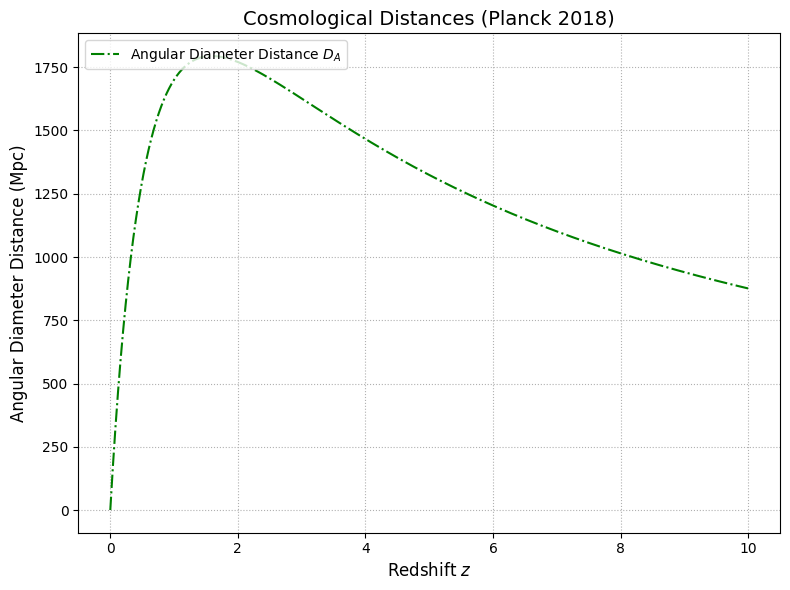

In [2]:
fig, ax = plt.subplots(figsize=(8, 6))

# 距離のプロット(左軸)
line = ax.plot(z_vals, D_A, 'g-.', label='Angular Diameter Distance $D_A$')
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel('Angular Diameter Distance (Mpc)', fontsize=12)
ax.grid(True, linestyle=':')
ax.legend(loc='upper left', fontsize=10)

plt.title('Cosmological Distances (Planck 2018)', fontsize=14)
plt.tight_layout()
plt.savefig('cosmology_plot_angular.png', dpi=300)
plt.show()